In [5]:
!pip install opencv-python

import cv2 as cv
import matplotlib.pyplot as vu
import numpy as np

(np.float64(-0.5), np.float64(199.5), np.float64(149.5), np.float64(-0.5))

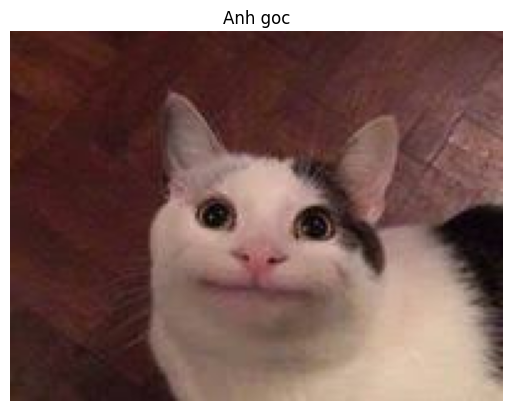

In [9]:
img = cv.imread('/content/hinh1.jpg')
img2 = cv.imread('/content/hinh2.jpg')

img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

vu.imshow(img)
vu.title("Anh goc")
vu.axis('off')

THRESHOLDING

Text(0.5, 1.0, 'Binary INV')

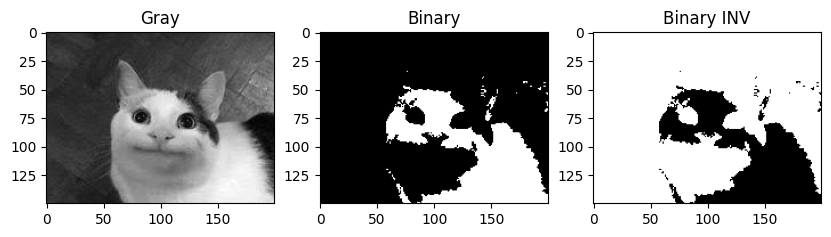

In [10]:
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

_, th1 = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)
_, th2 = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV)

vu.figure(figsize=(10,4))

vu.subplot(1,3,1)
vu.imshow(gray, cmap='gray')
vu.title("Gray")

vu.subplot(1,3,2)
vu.imshow(th1, cmap='gray')
vu.title("Binary")

vu.subplot(1,3,3)
vu.imshow(th2, cmap='gray')
vu.title("Binary INV")

OTSU

(np.float64(-0.5), np.float64(186.5), np.float64(269.5), np.float64(-0.5))

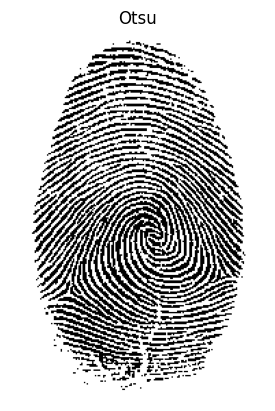

In [11]:
gray2 = cv.cvtColor(img2, cv.COLOR_RGB2GRAY)

_, otsu = cv.threshold(gray2, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

vu.imshow(otsu, cmap='gray')
vu.title("Otsu")
vu.axis('off')

K-MEANS CLUSTERING

(np.float64(-0.5), np.float64(199.5), np.float64(149.5), np.float64(-0.5))

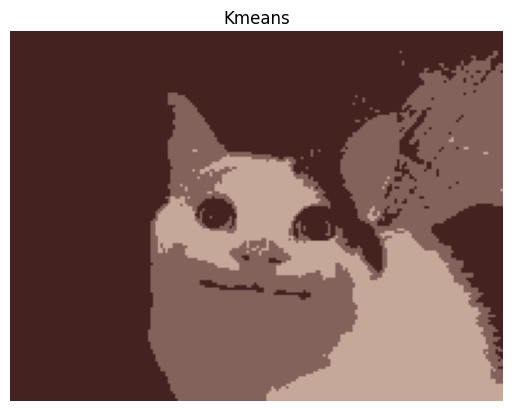

In [12]:
Z = img.reshape((-1,3))
Z = np.float32(Z)

K = 3
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

ret, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
kmeans_img = res.reshape((img.shape))

vu.imshow(kmeans_img)
vu.title("Kmeans")
vu.axis('off')

REGION GROWING

(np.float64(-0.5), np.float64(199.5), np.float64(149.5), np.float64(-0.5))

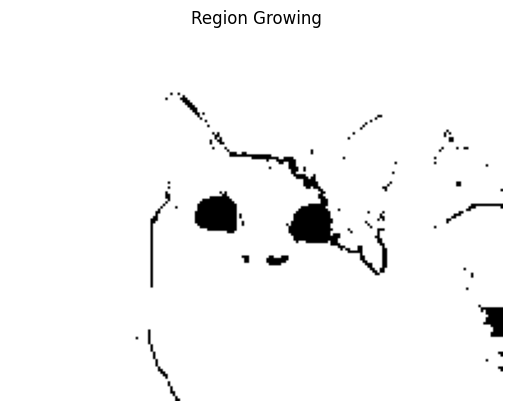

In [13]:
seed = (100,100)
threshold = 10

gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
seg = np.zeros_like(gray)

h, w = gray.shape
stack = [seed]

while stack:
    x, y = stack.pop()
    if seg[x,y] == 0:
        seg[x,y] = 255

        for dx in [-1,0,1]:
            for dy in [-1,0,1]:
                nx, ny = x+dx, y+dy
                if 0 <= nx < h and 0 <= ny < w:
                    if abs(int(gray[nx,ny]) - int(gray[x,y])) < threshold:
                        stack.append((nx,ny))

vu.imshow(seg, cmap='gray')
vu.title("Region Growing")
vu.axis('off')

SPLIT AND MERGE

(np.float64(-0.5), np.float64(199.5), np.float64(149.5), np.float64(-0.5))

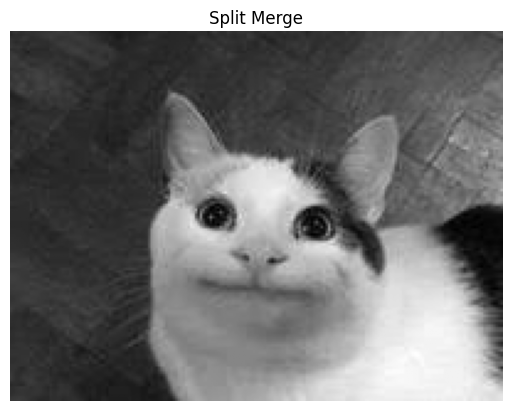

In [14]:
def split(img, thresh=10):
    h, w = img.shape
    if h < 2 or w < 2:
        return img

    if np.std(img) < thresh:
        return img

    h2, w2 = h//2, w//2

    q1 = split(img[:h2, :w2])
    q2 = split(img[:h2, w2:])
    q3 = split(img[h2:, :w2])
    q4 = split(img[h2:, w2:])

    top = np.hstack((q1,q2))
    bottom = np.hstack((q3,q4))

    return np.vstack((top,bottom))

gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
split_img = split(gray)

vu.imshow(split_img, cmap='gray')
vu.title("Split Merge")
vu.axis('off')

EDGE-BASED SEGMENTATION

(np.float64(-0.5), np.float64(199.5), np.float64(149.5), np.float64(-0.5))

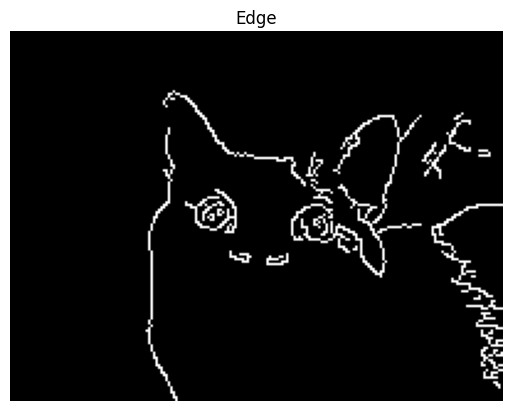

In [15]:
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

edges = cv.Canny(gray, 100, 200)

vu.imshow(edges, cmap='gray')
vu.title("Edge")
vu.axis('off')